In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([
    [4, 11],
    [8, 4],
    [13, 5],
    [7,14]]
)
X

array([[ 4, 11],
       [ 8,  4],
       [13,  5],
       [ 7, 14]])

In [3]:
X.shape

(4, 2)

In [4]:
X_mean = np.mean(X, axis=0)
X_mean

array([8. , 8.5])

In [5]:
X_centered = X - X_mean
X_centered

array([[-4. ,  2.5],
       [ 0. , -4.5],
       [ 5. , -3.5],
       [-1. ,  5.5]])

In [6]:
cov_matix = np.cov(X_centered, rowvar=False)
cov_matix

array([[ 14., -11.],
       [-11.,  23.]])

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matix)
eigenvalues, eigenvectors

(array([ 6.61513568, 30.38486432]),
 array([[-0.83025082,  0.55738997],
        [-0.55738997, -0.83025082]]))

In [8]:
sorted_idx = np.argsort(eigenvalues)[::-1]
print(f"Sorted Indices: {sorted_idx}")
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]
eigenvalues, eigenvectors

Sorted Indices: [1 0]


(array([30.38486432,  6.61513568]),
 array([[ 0.55738997, -0.83025082],
        [-0.83025082, -0.55738997]]))

In [16]:
components = eigenvectors[:, 0-1].reshape(2, 1)
components

array([[-0.83025082],
       [-0.55738997]])

In [17]:
PC = X_centered.dot(components)
PC

array([[ 1.92752836],
       [ 2.50825486],
       [-2.20038921],
       [-2.23539401]])

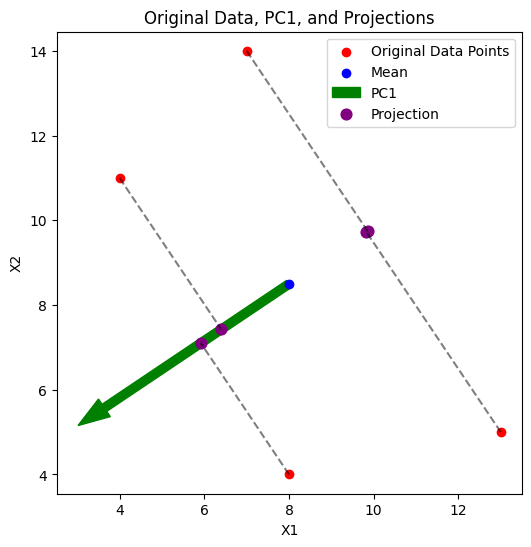

In [18]:
plt.figure(figsize=(6, 6))

# Plot original data points
plt.scatter(X[:, 0], X[:, 1], color='red', label='Original Data Points')

# Plot the mean
plt.scatter(X_mean[0], X_mean[1], color='blue', label='Mean', zorder=5)

# Plot the first principal component as an arrow
scale = 6  # scale for visualization
vec = components[:, 0] * scale
plt.arrow(X_mean[0], X_mean[1], vec[0], vec[1], color='green', width=0.2, label='PC1', head_width=0.5, length_includes_head=True)

# Plot projections of each data point onto PC1
for i in range(X.shape[0]):
    proj = X_mean + PC[i, 0] * components[:, 0]
    plt.plot([X[i, 0], proj[0]], [X[i, 1], proj[1]], 'k--', alpha=0.5)
    plt.scatter(proj[0], proj[1], color='purple', s=60, label='Projection' if i == 0 else "")

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Original Data, PC1, and Projections')
plt.legend()
plt.axis('equal')
plt.show()

### **PCA with Class method**

In [19]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        """
        n_components: number of principal components to keep
        """
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None

    def fit(self, X):
        """
        Fit the PCA model to dataset X.
        X: shape (n_samples, n_features)
        """
        # 1️⃣ Step 1: Center the data (zero mean)
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # 2️⃣ Step 2: Compute covariance matrix (d x d)
        # Cov = (1/n) * X^T X
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 3️⃣ Step 3: Compute eigenvalues & eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        # eigh is used because covariance matrix is symmetric

        # 4️⃣ Step 4: Sort eigenvalues (descending) and eigenvectors accordingly
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # 5️⃣ Step 5: Select top-k eigenvectors
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = eigenvalues[:self.n_components]

    def transform(self, X):
        """
        Project data onto the principal components
        """
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)

    def fit_transform(self, X):
        """
        Fit to data, then transform it
        """
        self.fit(X)
        return self.transform(X)


In [20]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1000, n_features=800, n_informative=10, n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (800, 800), X_test shape: (200, 800)


In [21]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(kernel='linear', random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_pred_rf = rf.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


SVM Accuracy: 0.73
Random Forest Accuracy: 0.745
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.72      0.76       120
           1       0.64      0.75      0.69        80

    accuracy                           0.73       200
   macro avg       0.72      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77       120
           1       0.65      0.79      0.71        80

    accuracy                           0.74       200
   macro avg       0.74      0.75      0.74       200
weighted avg       0.76      0.74      0.75       200



In [34]:
# Apply PCA to reduce to 1 dimension
pca = PCA(n_components=15)
X_reduced = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)


Original shape: (1000, 800)
Reduced shape: (1000, 15)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (800, 15), X_test shape: (200, 15)


In [36]:
svm = SVC(kernel='linear', random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_pred_rf = rf.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


SVM Accuracy: 0.785
Random Forest Accuracy: 0.855
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.73      0.80       120
           1       0.68      0.86      0.76        80

    accuracy                           0.79       200
   macro avg       0.79      0.80      0.78       200
weighted avg       0.81      0.79      0.79       200

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88       120
           1       0.79      0.86      0.83        80

    accuracy                           0.85       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.86      0.85      0.86       200

